In [42]:
import zipfile
import numpy as np
import gensim

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
# with zipfile.ZipFile("/mnt/e/Deep Learning/data/glove.2024.wikigiga.200d.zip", "r") as zip_ref:
#     zip_ref.extractall("/mnt/e/Deep Learning/data/")

In [3]:
data = {}
txt_path = "/mnt/e/Deep Learning/data/wiki_giga_2024_200_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05_combined.txt"

with open(txt_path, 'r', encoding='utf-8') as f:
    for line in f:
        word = line.split(" ")[0]
        vect = np.array(list(map(np.float32, line.split(" ")[1:])))
        data[word] = vect
        
    

In [4]:
print(f"Number of words in data: {len(data.keys())}")
print(f"Number of dim for every word:{list(data.values())[0].shape}")

Number of words in data: 1291147
Number of dim for every word:(200,)


In [7]:
from sklearn.metrics.pairwise import cosine_similarity

def similarity(u, v):
    return np.squeeze(cosine_similarity(u.reshape(1, -1), v.reshape(1, -1)))

In [9]:
father = data["father"]
mother = data["mother"]
ball = data["ball"]
crocodile = data["crocodile"]
france = data["france"]
tehran = data["tehran"]
paris = data["paris"]
iran = data["iran"]

print("cosine_similarity(father, mother) = ", similarity(father, mother))
print("cosine_similarity(ball, crocodile) = ", similarity(ball, crocodile))
print("cosine_similarity(france - paris, tehran - iran) = ", similarity(france - paris, tehran - iran))


cosine_similarity(father, mother) =  0.8250571
cosine_similarity(ball, crocodile) =  0.10655307
cosine_similarity(france - paris, tehran - iran) =  -0.50321025


In [ ]:
def complete_analogy(word_a, word_b, word_c, data):
    def similarity(u, v):
        return np.squeeze(cosine_similarity(u.reshape(1, -1), v.reshape(1, -1)))

    word_a, word_b, word_c = word_a.lower(), word_b.lower(), word_c.lower()
    
    vec_a, vec_b, vec_c = data[word_a], data[word_b], data[word_c]
    
    target_vec = vec_a - vec_b
    
    best_cos = -10
    best_word = [""]

    for word in data.keys():
        if word in [word_a, word_b, word_c]:
            continue

        sim = similarity(target_vec, vec_c - data[word])

        if sim > best_cos:
            best_cos = sim
            best_word[0] = word 

    return best_word[0], best_cos


In [18]:
complete_analogy("Tehran", "Iran", "Paris", data)

('france', array(0.50321025, dtype=float32))

In [20]:
import gensim.downloader as api

In [25]:
[model for model in api.info()['models'].keys()]

['fasttext-wiki-news-subwords-300',
 'conceptnet-numberbatch-17-06-300',
 'word2vec-ruscorpora-300',
 'word2vec-google-news-300',
 'glove-wiki-gigaword-50',
 'glove-wiki-gigaword-100',
 'glove-wiki-gigaword-200',
 'glove-wiki-gigaword-300',
 'glove-twitter-25',
 'glove-twitter-50',
 'glove-twitter-100',
 'glove-twitter-200',
 '__testing_word2vec-matrix-synopsis']

In [27]:
model = api.load("glove-twitter-50")

[==================================================] 100.0% 199.5/199.5MB downloaded


In [29]:
model.distance("apple", 'orange')

np.float32(0.31144625)

In [31]:
model.most_similar("orange")

[('blue', 0.8662261962890625),
 ('red', 0.8619911670684814),
 ('green', 0.8573964238166809),
 ('purple', 0.8513275980949402),
 ('yellow', 0.8417329788208008),
 ('white', 0.8266170024871826),
 ('cherry', 0.821728527545929),
 ('lime', 0.8082377314567566),
 ('mint', 0.8061325550079346),
 ('ice', 0.8013647794723511)]

In [33]:
model.most_similar("iran")

[('iraq', 0.8729350566864014),
 ('libya', 0.8580341935157776),
 ('syrian', 0.8261938691139221),
 ('syria', 0.8138160109519958),
 ('assad', 0.8136308193206787),
 ('iranian', 0.8122655153274536),
 ('israel', 0.805794358253479),
 ('afghanistan', 0.7974693775177002),
 ('ukraine', 0.7919898629188538),
 ('warns', 0.7768937349319458)]

In [35]:
model.most_similar_cosmul(positive=["king", "woman"], negative=["queen"])

[('guy', 0.9372048377990723),
 ('fish', 0.9327573776245117),
 ('father', 0.9304196238517761),
 ('known', 0.9300268888473511),
 ('shooter', 0.9261264801025391),
 ('man', 0.9256263375282288),
 ('person', 0.9248374700546265),
 ('death', 0.9234976172447205),
 ('side', 0.9231244921684265),
 ('killed', 0.9230132102966309)]

In [46]:
words = ['father', 'mother', 'king', 'queen', 'blue', 'green', 'iran', 'tehran']

embedings = np.array([data[word] for word in words])
print(embedings.shape)

(8, 200)


In [47]:
pca = PCA(n_components=2)
components = pca.fit_transform(embedings)

In [48]:
components.shape

(8, 2)

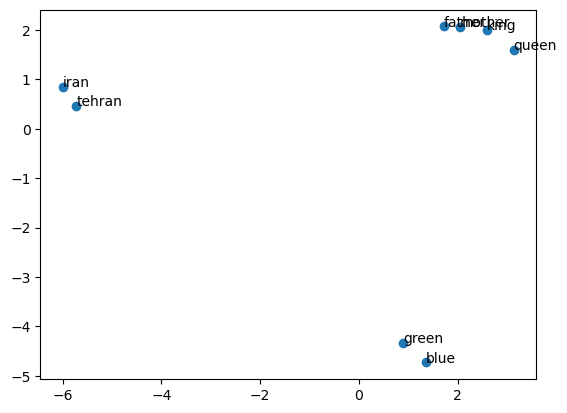

In [49]:
plt.scatter(components[:, 0], components[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, (components[i, 0], components[i, 1]))